<img src="https://datasciencedegree.wisconsin.edu/wp-content/themes/data-gulp/images/logo.svg" width="300">

 # <center>DS 710 - Lesson 6b</center>

This notebook will work through some basics of plotting with matplotlib, seaborn, and pandas.

References for the material in this notebook include 
* Chapter 9 of *Python for Data Analysis*, and 
* the documentation for <a href="https://matplotlib.org/3.3.2/contents.html#">matplotlib</a>, <a href="https://seaborn.pydata.org/">seaborn</a>, <a href="https://plotly.com/python/getting-started/">Plotly</a> and <a href="https://pandas.pydata.org/pandas-docs/stable/user_guide/visualization.html">pandas</a>.

I'll also add that there are *many* ways to make plots in Python.  This notebook shows some, but is not exhaustive -- that would be impossible!  Find your own way in your plotting adventure.

---

### Plotting with seaborn & pandas

Let's import pandas, and open the file `energy-gen-WA.csv` (which, of course, you should have saved in the same directory as this notebook).

In [1]:
import pandas as pd
energy_WA = pd.read_csv('energy-gen-WA.csv')
energy_WA.head(20)

,YEAR,ENERGY_SOURCE,GENERATION_MWh
0,1990,Total,"102,071,533"
1,1990,Coal,"7,390,279"
2,1990,Hydroelectric Conventional,"87,466,708"
3,1990,Natural Gas,"288,058"
4,1990,Nuclear,"5,742,027"
5,1990,Other,"3,750"
6,1990,Other Biomass,"6,499"
7,1990,Other Gases,"8,460"
8,1990,Petroleum,"42,981"
9,1990,Pumped Storage,0


🧠 Take a moment to use what you learned in the previous lesson to explore this data.

In [4]:
energy_WA.shape

(356, 3)

One thing you will want to check before we try to plot column values using seaborn is that the columns you think are numerical are actually numerical:

In [5]:
energy_WA.dtypes

YEAR              int64
ENERGY_SOURCE       str
GENERATION_MWh      str
dtype: object

Oh no! We want the number of megawatt-hours (MWhs) generated by each source to be numerical values, but right now they are objects. No problem: let's remove the commas in the values and convert to integers.

In [6]:
energy_WA['GENERATION_MWh'] = energy_WA['GENERATION_MWh'].str.replace(",","").astype(int)
energy_WA.dtypes

YEAR              int64
ENERGY_SOURCE       str
GENERATION_MWh    int64
dtype: object

Now, we'll graph the energy generation against the year.

<Axes: xlabel='YEAR', ylabel='GENERATION_MWh'>

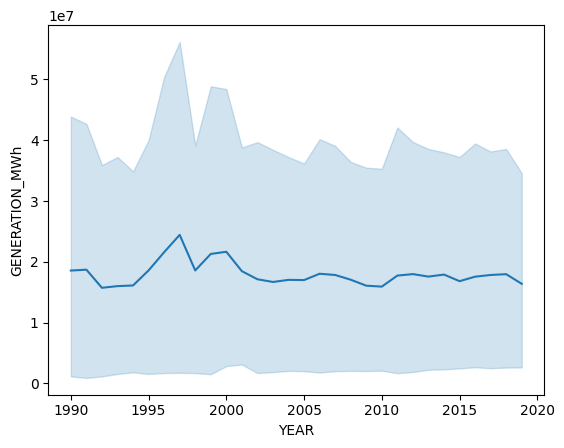

In [7]:
import seaborn as sns
sns.lineplot(data=energy_WA, x='YEAR', y='GENERATION_MWh')

Notice that there are multiple rows corresponding to the same year: seaborn interpreted this by graphing the mean across all rows of the same year, along with a confidence interval (shaded). But this probably isn't what we wanted. Instead, we can separate out the rows with the same year according to the energy source, as follows. 

<Axes: xlabel='YEAR', ylabel='GENERATION_MWh'>

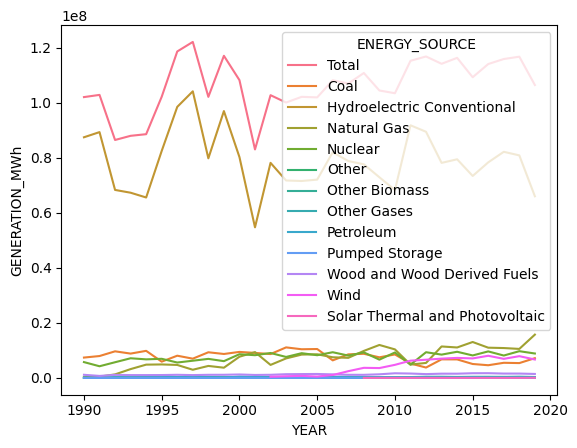

In [9]:
sns.lineplot(data=energy_WA, x='YEAR', y='GENERATION_MWh', hue='ENERGY_SOURCE')

Now, of course, our issue is a fairly unreadable graph due to a giant legend. If we want, we can take away the legend.

<Axes: xlabel='YEAR', ylabel='GENERATION_MWh'>

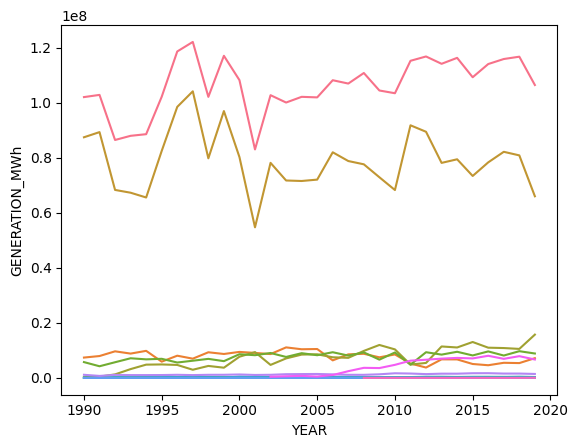

In [10]:
sns.lineplot(data=energy_WA, x='YEAR', y='GENERATION_MWh', hue='ENERGY_SOURCE', legend=False)

However, we actually do want to know which energy source is generating each line. So, we can resize the figure to make room for the legend as follows:

<Axes: xlabel='YEAR', ylabel='GENERATION_MWh'>

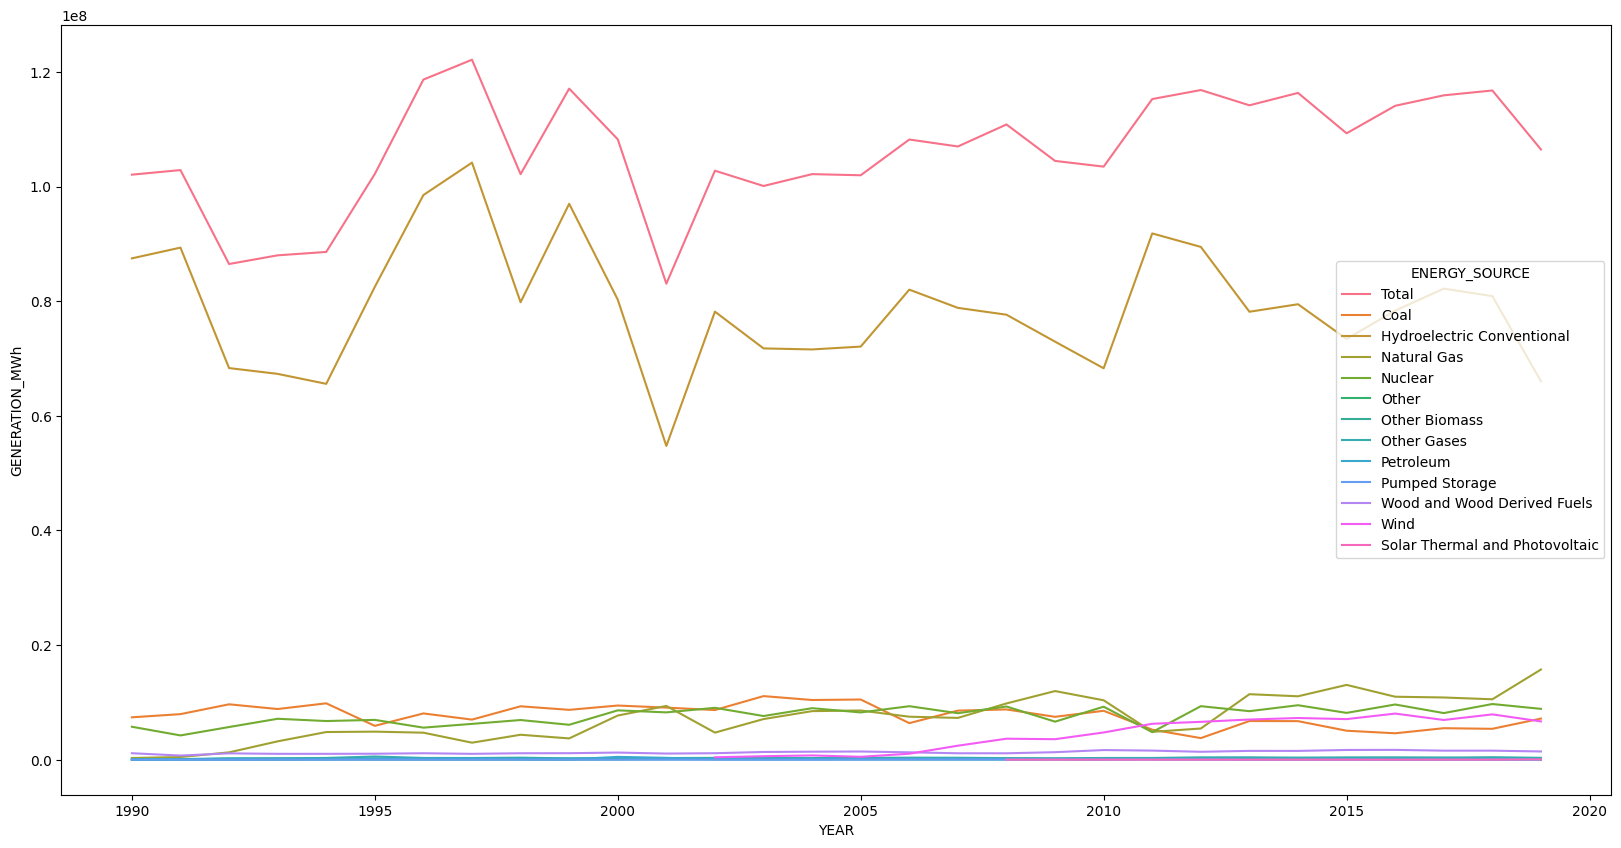

In [11]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(20,10))
sns.lineplot(data=energy_WA, ax=ax, x='YEAR', y='GENERATION_MWh', hue='ENERGY_SOURCE')

If we only care about particular energy sources, we may want to make each energy source into its own column using a pivot table. Note that we fill all empty entries with a "0".

In [12]:
pvt_energy_WA = pd.pivot_table(energy_WA, index=['YEAR'],columns=['ENERGY_SOURCE']).fillna(0)
pvt_energy_WA.head()

GENERATION_MWh                                         \
ENERGY_SOURCE           Coal Hydroelectric Conventional Natural Gas   
YEAR                                                                  
1990               7390279.0                 87466708.0    288058.0   
1991               7944779.0                 89342397.0    460424.0   
1992               9658148.0                 68324659.0   1273763.0   
1993               8835079.0                 67312383.0   3197945.0   
1994               9831332.0                 65575487.0   4820582.0   

                                                                       \
ENERGY_SOURCE    Nuclear    Other Other Biomass Other Gases Petroleum   
YEAR                                                                    
1990           5742027.0   3750.0        6499.0      8460.0   42981.0   
1991           4229868.0      3.0       46633.0     97467.0   31164.0   
1992           5692379.0      1.0      172810.0    234023.0   25745.0   
1993           7134966.0      7.0      214990.0    222852.0   59434.0   
1994           6739749.0  31282.0      224804.0    299161.0   45419.0   

                                                                               \
ENERGY_SOURCE Pumped Storage Solar Thermal and Photovoltaic        Total Wind   
YEAR                                                                            
1990                     0.0                            0.0  102071533.0  0.0   
1991                     0.0                            0.0  102870562.0  0.0   
1992                     0.0                            0.0   86482429.0  0.0   
1993                     0.0                            0.0   87995776.0  0.0   
1994                     0.0                            0.0   88586476.0  0.0   

                                           
ENERGY_SOURCE Wood and Wood Derived Fuels  
YEAR                                       
1990                            1122771.0  
1991                             717827.0  
1992                            1100901.0  
1993                            1018120.0  
1994                            1018660.0

Now we can plot and adjust the location of the legend, the title, and the axes labels.

Text(0, 0.5, 'MWh')

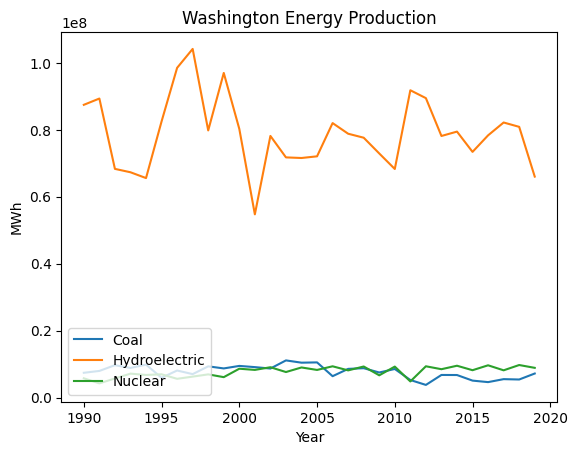

In [13]:
sns.lineplot(data=pvt_energy_WA['GENERATION_MWh','Coal'], label = 'Coal')
sns.lineplot(data=pvt_energy_WA['GENERATION_MWh','Hydroelectric Conventional'], label = 'Hydroelectric')
sns.lineplot(data=pvt_energy_WA['GENERATION_MWh','Nuclear'], label = 'Nuclear')
plt.legend(loc='lower left')
plt.title('Washington Energy Production')
plt.xlabel('Year')
plt.ylabel('MWh')

We can also use pandas to plot. Suppose we want to create a stacked bar plot that gives the breakdown of megawatt-hours produced for each energy source in a given year. First, we remove the `'Total'` column, as this is just the sum of the other columns, and will appear as the total height of our stacked columns.

In [14]:
pvt_energy_WA = pvt_energy_WA.drop(columns = [('GENERATION_MWh', 'Total')])

Finally, we'll create a stacked bar plot, using `alpha` to specify the opacity of the bars.

Text(0, 0.5, 'MWh')

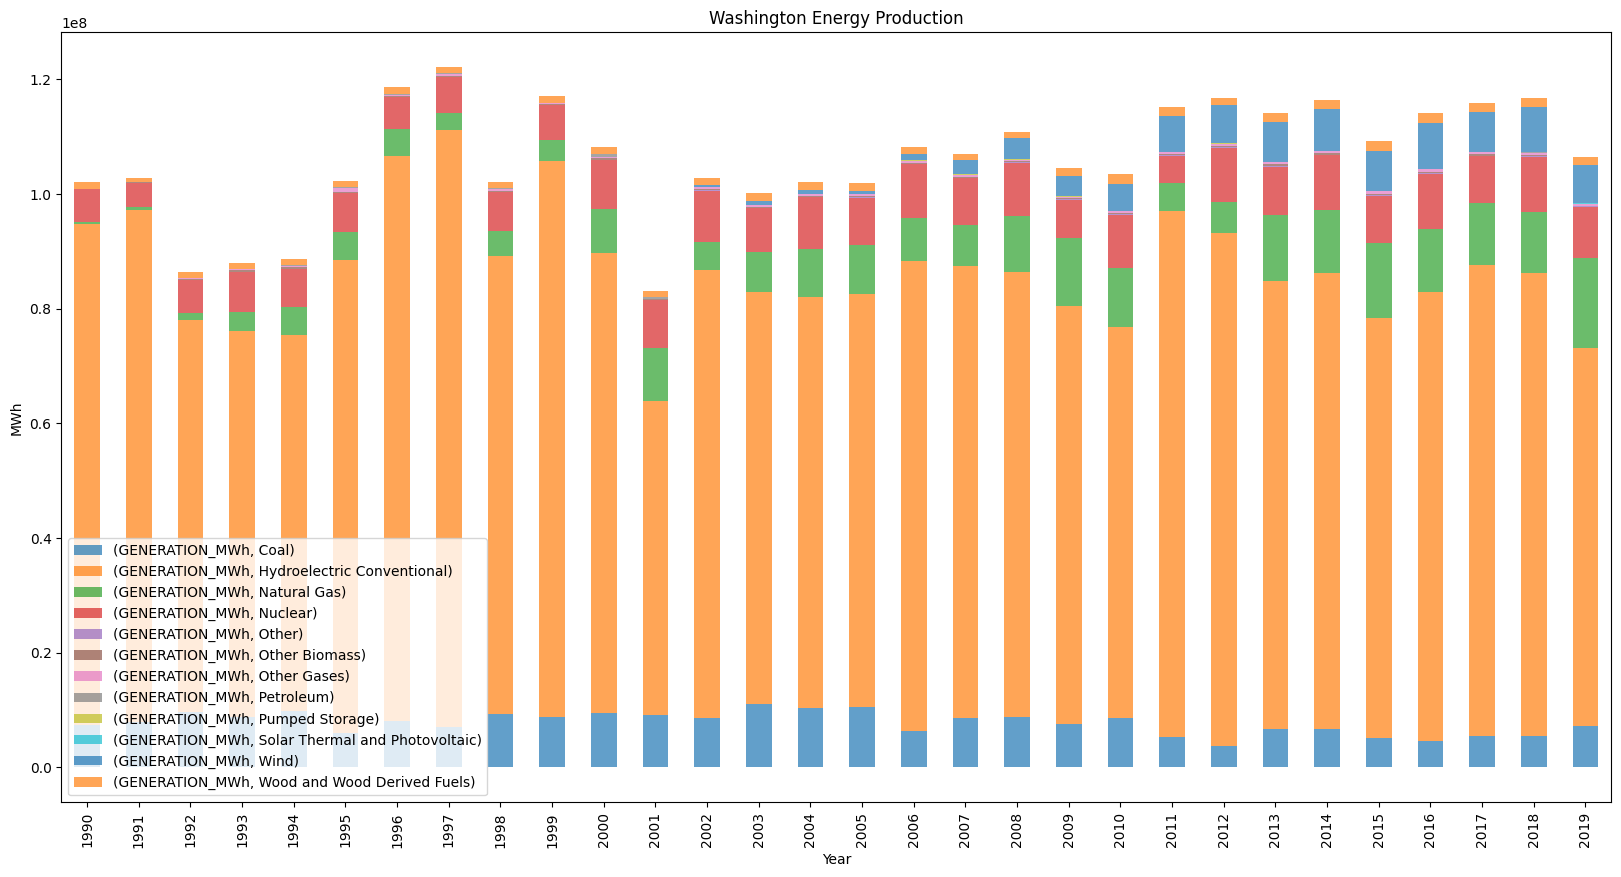

In [15]:
fig, ax = plt.subplots(figsize=(20,10))
pvt_energy_WA.plot.bar(stacked=True, alpha=0.7, ax=ax)
plt.legend(loc='lower left', )
plt.title('Washington Energy Production')
plt.xlabel('Year')
plt.ylabel('MWh')

---

### Plotting with Plotly

The plotly libary is an incredible tool that really expands the possibilities of the kinds of charts we can make.

Explore the myriad of examples [here](https://plotly.com/python/).

Let's see what we can do with a "Wind Rose Chart", which is essentially a circular bar chart.

In [16]:
import plotly.express as px

# First we assign every year with an angle between 0 and 360 degrees.

year_min = energy_WA["YEAR"].min()
year_max = energy_WA["YEAR"].max()
year_diff = year_max-year_min

energy_WA['YEAR_ANGLE'] = (energy_WA["YEAR"]-year_min)*360/(year_diff+1)

# And now we use bar_polar

fig = px.bar_polar(energy_WA, r="GENERATION_MWh", theta="YEAR_ANGLE",   
                    color="ENERGY_SOURCE")
fig.show()

Before going further, I have a few notes for you on this one.

Notice that as you hover over the graph, a box pops up and tells you the values associated to that slice.

We can also click on the different energy sources to toggle them.  

🎯Toggle the `Total` energy source to get a better picture of the compared energy sources.

🎯 Create a new dataframe that omits the rows where the `"ENERGY_SOURCE"` column has the value `"Total"`.

🎯 Recreate this Wind Rose Plot using your new dataframe.



### 3D Plotting with Plotly

Here we will present an example of a 3D Plotly plot with synthetic data, just for illustration purposes.

In [17]:
# Retry generating the curved surface plot

# %%
import numpy as np
import plotly.graph_objects as go

def make_random_surface(x_range=(-2.5, 2.5), y_range=(-2.5, 2.5), n_grid=120, seed=None):
    rng = np.random.default_rng()
    x = np.linspace(*x_range, n_grid)
    y = np.linspace(*y_range, n_grid)
    X, Y = np.meshgrid(x, y)

    a1, a2, a3 = rng.uniform(-0.6, 0.6, size=3)
    b1, b2 = rng.uniform(0.6, 2.0, size=2)
    c1, c2 = rng.uniform(-1.0, 1.0, size=2)
    d1, d2 = rng.uniform(-0.3, 0.3, size=2)

    Z = (
        a1 * X**2
        + a2 * Y**2
        + a3 * X * Y
        + c1 * np.sin(b1 * X)
        + c2 * np.cos(b2 * Y)
        + d1 * X**3 / 3.0
        + d2 * Y**3 / 3.0
    )

    def f(xp, yp):
        return (
            a1 * xp**2
            + a2 * yp**2
            + a3 * xp * yp
            + c1 * np.sin(b1 * xp)
            + c2 * np.cos(b2 * yp)
            + d1 * xp**3 / 3.0
            + d2 * yp**3 / 3.0
        )

    return X, Y, Z, f

def sample_noisy_points(surface_fn, n_points=350, x_range=(-2.5, 2.5), y_range=(-2.5, 2.5), noise_std=0.18, seed=7):
    rng = np.random.default_rng()
    xs = rng.uniform(x_range[0], x_range[1], size=n_points)
    ys = rng.uniform(y_range[0], y_range[1], size=n_points)
    zs_true = surface_fn(xs, ys)
    zs_noisy = zs_true + rng.normal(0.0, noise_std, size=n_points)
    return xs, ys, zs_true, zs_noisy

# Generate surface and data
X, Y, Z, surface_fn = make_random_surface()
xs, ys, zs_true, zs_noisy = sample_noisy_points(surface_fn)

# Create figure
fig = go.Figure()

fig.add_trace(go.Surface(x=X, y=Y, z=Z, opacity=0.22, showscale=False))
fig.add_trace(go.Scatter3d(x=xs, y=ys, z=zs_noisy, mode="markers", marker=dict(size=2.5, color="black")))

fig.update_layout(
    title="Arbitrary Curved Surface with Noisy Sampled Data",
    scene=dict(xaxis_title="x", yaxis_title="y", zaxis_title="z", aspectmode="data"),
    margin=dict(l=0, r=0, b=0, t=40),
)

fig.show()
# %%


Now try this excercise

In [18]:
# %%

# =============================================================================
# DS 710 – Programming for Data Science
# Exercise: 3D Visualization with Plotly
# =============================================================================
#
# In this exercise you will:
#   Step 1 – Load synthetic data into a pandas DataFrame
#   Step 2 – Extract variables into arrays for plotting
#   Step 3 – Build an interactive 3D figure combining a surface and a scatter plot
#
# Run the script when each step is complete to check your work.
# A reference solution is commented out at the bottom of the file.
# =============================================================================

import numpy as np
import pandas as pd
import plotly.graph_objects as go

# -----------------------------------------------------------------------------
# Synthetic data generation  (do not modify this block)
# -----------------------------------------------------------------------------

SEED = 42
rng  = np.random.default_rng(SEED)

# --- Surface grid ---
grid_points = 60                          # resolution along each axis
x_vals = np.linspace(-3, 3, grid_points)
y_vals = np.linspace(-3, 3, grid_points)
X, Y  = np.meshgrid(x_vals, y_vals)

# True surface: Z = sin(X) * cos(Y)
Z_surface = np.sin(X) * np.cos(Y)

# --- Noisy scatter sample ---
n_samples    = 400
x_sample     = rng.uniform(-3, 3, n_samples)
y_sample     = rng.uniform(-3, 3, n_samples)
noise        = rng.normal(loc=0, scale=0.25, size=n_samples)
z_sample     = np.sin(x_sample) * np.cos(y_sample) + noise   # true value + noise

# Pack the scatter sample into a DataFrame
df = pd.DataFrame({
    "x": x_sample,
    "y": y_sample,
    "z": z_sample,
})

print("DataFrame shape:", df.shape)
print(df.head())


# =============================================================================
# STEP 1 – Load data into a DataFrame
# =============================================================================
# The DataFrame `df` has already been created above with columns "x", "y", "z".
#
# Your task:
#   (a) Print a summary of the DataFrame so you know what you are working with.
#       Use .describe() to see basic statistics for each column.
#   (b) Confirm there are no missing values with .isna().sum().
# =============================================================================

# TODO (a): print df.describe()
print(df.describe())

# TODO (b): print the count of missing values per column
print(df.isna().sum())



# =============================================================================
# STEP 2 – Extract variables into arrays
# =============================================================================
# Plotly's graph objects work directly with NumPy arrays.
#
# Your task:
#   (a) Extract the "x", "y", and "z" columns from df into three separate
#       1-D NumPy arrays called x_pts, y_pts, z_pts.
#       Hint: pandas Series have a .to_numpy() method.
#
#   (b) The surface arrays X, Y, Z_surface were already created above as 2-D
#       NumPy arrays (shape 60×60).  No extra work needed – just note that
#       go.Surface expects 2-D arrays while go.Scatter3d expects 1-D arrays.
# =============================================================================

# TODO (a): extract x_pts, y_pts, z_pts from df
x_pts = df["x"].to_numpy()
y_pts = df["y"].to_numpy()
z_pts = df["z"].to_numpy()

print("x_pts shape:", x_pts.shape)   # expected: (400,)



# =============================================================================
# STEP 3 – Build the 3D figure
# =============================================================================
# You will create a figure with two traces:
#   • A surface trace  (go.Surface)  for the smooth mathematical function
#   • A scatter trace  (go.Scatter3d) for the noisy sample points
#
# Then you will update the layout to add titles, tweak the camera, and
# enable a few interactive features.
# =============================================================================

# --- 3a: Create the surface trace -------------------------------------------
# go.Surface takes 2-D arrays for x, y, z.
# Fill in the blanks; each ___ should be replaced with the correct value.

surface_trace = go.Surface(
    x          = X,                   # 2-D grid of x values
    y          = Y,                   # 2-D grid of y values
    z          = Z_surface,           # 2-D grid of z values
    colorscale = "RdBu",             # TODO: pick a colorscale
                                      #   options: "Viridis", "RdBu", "Plasma",
                                      #            "Turbo", "Electric", …
    opacity    = 0.7,                 # TODO: float between 0 and 1
                                      #   try 0.7 so the scatter dots show through
    colorbar   = dict(title="Z"),
    name       = "sin(x)·cos(y)",
)

# --- 3b: Create the scatter trace -------------------------------------------
# go.Scatter3d takes 1-D arrays for x, y, z.

scatter_trace = go.Scatter3d(
    x    = x_pts,
    y    = y_pts,
    z    = z_pts,
    mode = "markers",
    marker = dict(
        size  = 3,            # TODO: marker size in pixels – try values between 2–5
        color = "black",      # TODO: set to "black" as specified
        opacity = 0.6,
    ),
    # Hover template – %{x:.2f} formats the x value to 2 decimal places
    hovertemplate = (
        "x: %{x:.2f}<br>"
        "y: %{y:.2f}<br>"
        "z (noisy): %{z:.2f}<extra></extra>"
    ),
    name = "Noisy samples",
)

# --- 3c: Assemble the figure -------------------------------------------------

fig = go.Figure(data=[surface_trace, scatter_trace])

# --- 3d: Customise the layout ------------------------------------------------
# Update axis labels, add a title, and set an initial camera position.
# The camera dict positions the virtual "eye" in (x, y, z) scene coordinates.

fig.update_layout(
    title = dict(
        text     = "3D Surface: sin(x)·cos(y) with Noisy Samples",   # TODO: give the figure a descriptive title
        font     = dict(size=18),
        x        = 0.5,                 # centre the title
        xanchor  = "center",
    ),
    scene = dict(
        xaxis = dict(title="x"),                  # TODO: axis label for x  (e.g. "x")
        yaxis = dict(title="y"),                  # TODO: axis label for y  (e.g. "y")
        zaxis = dict(title="z = sin(x)·cos(y)"),  # TODO: axis label for z  (e.g. "z = sin(x)·cos(y)")
        camera = dict(
            eye = dict(x=1.6, y=1.6, z=0.8),   # try tweaking these values
        ),
    ),
    legend = dict(
        x=0.01, y=0.99,
        bgcolor="rgba(255,255,255,0.7)",
        bordercolor="lightgrey",
        borderwidth=1,
    ),
    margin = dict(l=0, r=0, t=60, b=0),
    width  = 900,
    height = 650,
)

# --- 3e: Interactive features ------------------------------------------------
# Plotly figures are interactive by default (rotate, zoom, pan).
# The snippet below adds a dropdown menu that lets the viewer switch
# between two colorscales without re-running the script.
# Read through it – you do not need to modify it, just fill in the one blank.

fig.update_layout(
    updatemenus=[
        dict(
            buttons=[
                dict(label="Viridis",
                     method="restyle",
                     args=[{"colorscale": "Viridis"}, [0]]),   # [0] = surface trace
                dict(label="RdBu",
                     method="restyle",
                     args=[{"colorscale": "RdBu"}, [0]]),
                dict(label="Turbo",
                     method="restyle",
                     args=[{"colorscale": "Turbo"}, [0]]),
            ],
            direction = "down",
            showactive = True,
            x=0.01, xanchor="left",
            y=0.90, yanchor="top",
            bgcolor="white",
            bordercolor="lightgrey",
        )
    ]
)

# --- 3f: Render the figure ---------------------------------------------------
# show() opens the figure in your default browser as an interactive HTML page.
# You can rotate, zoom, pan, and hover over points.

fig.show()

# Optional – uncomment to save a standalone HTML file you can share:
# fig.write_html("3d_surface_scatter.html")


# =============================================================================
# REFERENCE SOLUTION  (read only after attempting the exercise yourself)
# =============================================================================
#
# Step 1
# ------
# print(df.describe())
# print(df.isna().sum())
#
# Step 2
# ------
# x_pts = df["x"].to_numpy()
# y_pts = df["y"].to_numpy()
# z_pts = df["z"].to_numpy()
#
# Step 3 – blanks filled in
# -------------------------
# surface_trace = go.Surface(
#     x          = X,
#     y          = Y,
#     z          = Z_surface,
#     colorscale = "RdBu",
#     opacity    = 0.7,
#     colorbar   = dict(title="Z"),
#     name       = "sin(x)·cos(y)",
# )
#
# scatter_trace = go.Scatter3d(
#     x    = x_pts,
#     y    = y_pts,
#     z    = z_pts,
#     mode = "markers",
#     marker = dict(
#         size    = 3,
#         color   = "black",
#         opacity = 0.6,
#     ),
#     hovertemplate = (
#         "x: %{x:.2f}<br>"
#         "y: %{y:.2f}<br>"
#         "z (noisy): %{z:.2f}<extra></extra>"
#     ),
#     name = "Noisy samples",
# )
#
# fig.update_layout(
#     title = dict(text="3D Surface: sin(x)·cos(y) with Noisy Samples", ...),
#     scene = dict(
#         xaxis = dict(title="x"),
#         yaxis = dict(title="y"),
#         zaxis = dict(title="z = sin(x)·cos(y)"),
#         ...
#     ),
#     ...
# )
# =============================================================================
# %%


DataFrame shape: (400, 3)
          x         y         z
0  1.643736 -1.188436  0.804368
1 -0.366729  2.510651  0.629336
2  2.151588  1.687764 -0.033762
3  1.184208 -2.336470 -0.304222
4 -2.434936  2.982208  0.644078
                x           y           z
count  400.000000  400.000000  400.000000
mean    -0.020722   -0.046474    0.047614
std      1.710145    1.777316    0.546169
min     -2.955826   -2.992602   -1.477743
25%     -1.560515   -1.577892   -0.363848
50%     -0.051419   -0.037705    0.042453
75%      1.549174    1.516829    0.463543
max      2.954253    2.994628    1.185061
x    0
y    0
z    0
dtype: int64
x_pts shape: (400,)


#### Styling

Now let's customize our figure.  There are many options for customization.

The documentation you may want to reference for this particular plot is here

* [Layout](https://plotly.com/python/reference/layout/) - general plotly figure layout customization
* [Layout -> Polar](https://plotly.com/python/reference/layout/polar/) - figure layout for plots on polar axes

Below I have updated the tick labels on the angular axis using two arguments:
    * `angularaxis_tickvals` - the angles where the ticks are located
    * `angularaxis_ticktext` - the text to appear at the given angles

🎯 Update the new figure that you created that does not include the `Total` energy source wit these tick labels.

🎯 Update the labels so that only every other year appears.

🎯 Change the appearance of the radial axis ticks to be more useful.

🎯 Add a title to the plot.

🎯 Change the "ENERGY_SOURCE" label in the legend to "Energy Source".

🎯 Explore color scales and select one that might better suite the data. See the [Built-In Color Scales](https://plotly.com/python/builtin-colorscales/) and [Colorscale layout documentation](https://plotly.com/python/reference/layout/#layout-colorscale).

In [19]:
fig.update_polars(
    angularaxis_tickvals = [ii*360/(year_diff+1) for ii in range(year_diff+1)],
    angularaxis_ticktext = [ii for ii in range(year_min, year_max+1)]
)
fig.show()

---

## When you're done

🧠 After completing the guided practice above, log onto Canvas to complete Quiz 6b. You may wish to keep this notebook open while you work.

## Credits

First version developed by Allison Beemer, Summer 2020.  Revised by Mckenzie West and silviana amethyst 2021, 2022, 2023, 2024.

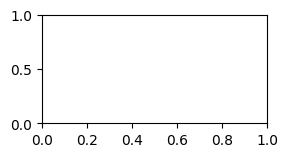

In [20]:
fig_ex = plt.figure()
plot_1 = fig_ex.add_subplot(3, 2, 1)